In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/i1.csv")
dg=pd.read_csv("/content/i2.csv")

In [ ]:
df.shape

(7242, 16)

In [ ]:
dg.shape

(8379, 16)

In [ ]:
dh=df.merge(dg,how='outer')
dh

,Date,Timestamp,Invoice No.,Item Name,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Server Name,Covers,Variation,Category,HSN
0,2023-04-01,2023-04-01 13:16:03,23465,Babycorn Manchurian,160.0,1.0,160.0,0.0,8.00,168.00,20.0,biller,0,NaN,Veg Starters,NaN
1,2023-04-01,2023-04-01 13:16:03,23465,Chicken Kati Roll,120.0,1.0,120.0,0.0,6.00,126.00,20.0,biller,0,NaN,NON VEG STARTERS CHICKEN,NaN
2,2023-04-01,2023-04-01 13:16:03,23465,Paneer Butter Masala,150.0,2.0,300.0,0.0,15.00,315.00,20.0,biller,0,NaN,Veg Gravy,NaN
3,2023-04-01,2023-04-01 13:16:03,23465,Pulka (2 No),40.0,3.0,120.0,0.0,6.00,126.00,20.0,biller,0,NaN,Indian Breads,NaN
4,2023-04-01,2023-04-01 13:16:03,23465,Schewan Chicken Fried Rice,160.0,1.0,160.0,0.0,8.00,168.00,20.0,biller,0,NaN,NON VEG BRIYANI & RICE,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15616,2023-09-19,2023-09-19 22:03:44,28389,Kulcha,55.0,1.0,55.0,0.0,2.76,57.76,16.0,biller,0,NaN,Indian Breads,NaN
15617,2023-09-19,2023-09-19 22:03:44,28389,Mineral Water,20.0,2.0,40.0,0.0,2.00,42.00,16.0,biller,0,NaN,Deserts & Mocktails,NaN
15618,2023-09-19,2023-09-19 22:03:44,28389,Mushroom Masala,150.0,1.0,150.0,0.0,7.50,157.50,16.0,biller,0,NaN,Veg Gravy,NaN
15619,2023-09-19,2023-09-19 22:03:44,28389,Paneer Butter Masala,150.0,1.0,150.0,0.0,7.50,157.50,16.0,biller,0,NaN,Veg Gravy,NaN


In [ ]:
df.shape

(7242, 16)

In [ ]:
dh.isnull().sum()


,0
Date,0
Timestamp,0
Invoice No.,0
Item Name,0
Price,0
Qty.,0
Sub Total,0
Discount,0
Tax,0
Final Total,0


In [ ]:
dh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15621 entries, 0 to 15620
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         15621 non-null  object 
 1   Timestamp    15621 non-null  object 
 2   Invoice No.  15621 non-null  int64  
 3   Item Name    15621 non-null  object 
 4   Price        15621 non-null  float64
 5   Qty.         15621 non-null  float64
 6   Sub Total    15621 non-null  float64
 7   Discount     15621 non-null  float64
 8   Tax          15621 non-null  float64
 9   Final Total  15621 non-null  float64
 10  Table No.    15613 non-null  float64
 11  Server Name  15621 non-null  object 
 12  Covers       15621 non-null  int64  
 13  Variation    15 non-null     object 
 14  Category     15621 non-null  object 
 15  HSN          0 non-null      float64
dtypes: float64(8), int64(2), object(6)
memory usage: 1.9+ MB


In [ ]:
dh.describe()

,Invoice No.,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Covers,HSN
count,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15613.000000,15621.0,0.0
mean,25989.963127,116.608988,1.338839,147.407080,1.262818,7.303668,153.447930,18.068340,0.0,NaN
std,1433.192998,63.663769,0.949814,210.127442,6.656396,10.461474,219.678163,17.191377,0.0,NaN
min,23465.000000,12.000000,1.000000,12.000000,0.000000,0.000000,12.600000,1.000000,0.0,NaN
25%,24751.000000,50.000000,1.000000,80.000000,0.000000,4.000000,84.000000,4.000000,0.0,NaN
50%,25980.000000,140.000000,1.000000,150.000000,0.000000,7.000000,147.000000,12.000000,0.0,NaN
75%,27274.000000,160.000000,1.000000,170.000000,0.000000,8.500000,178.500000,26.000000,0.0,NaN
max,28389.000000,770.000000,28.000000,21560.000000,288.000000,1078.000000,22638.000000,50.000000,0.0,NaN


In [ ]:
columns_to_handle = ['Server Name', 'Discount', 'Table No.', 'Covers', 'HSN']

dh2 = dh.dropna(subset=columns_to_handle, axis=0)

In [ ]:
sumofFT=dh['Final Total'].sum()
print(sumofFT)

2397010.12


In [ ]:
dh['Invoice No.'].nunique()

4925

In [ ]:
dh['Final Total'].sum()/dh['Invoice No.'].nunique()

np.float64(486.70256243654825)

In [ ]:
a=dh.groupby('Item Name')['Qty.'].sum().sort_values(ascending=False)[0:5]

<Axes: xlabel='Item Name', ylabel='Qty.'>

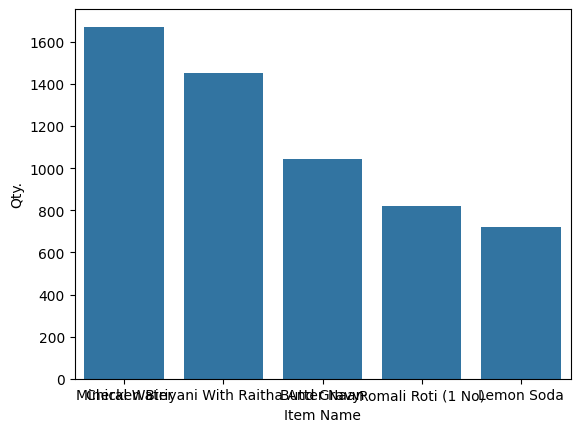

In [ ]:
sns.barplot(a)

<Axes: xlabel='Item Name'>

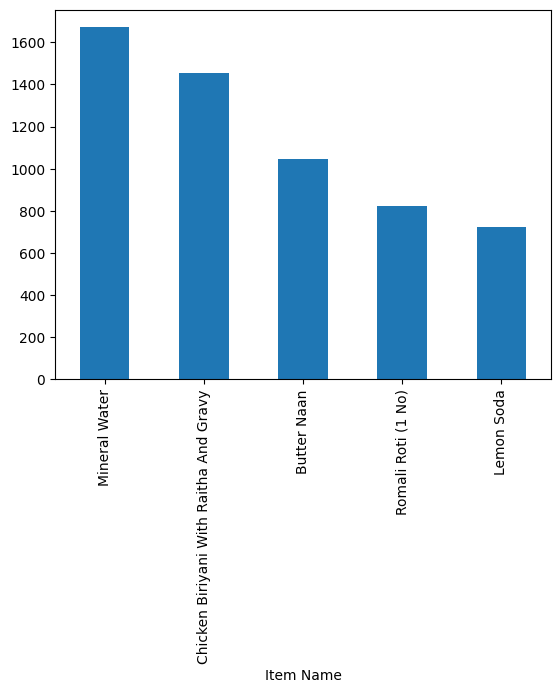

In [ ]:
#OR
a.plot(kind='bar')

In [ ]:
b=a=dh.groupby('Item Name')['Final Total'].sum().sort_values(ascending=False)[0:5]

<Axes: xlabel='Item Name'>

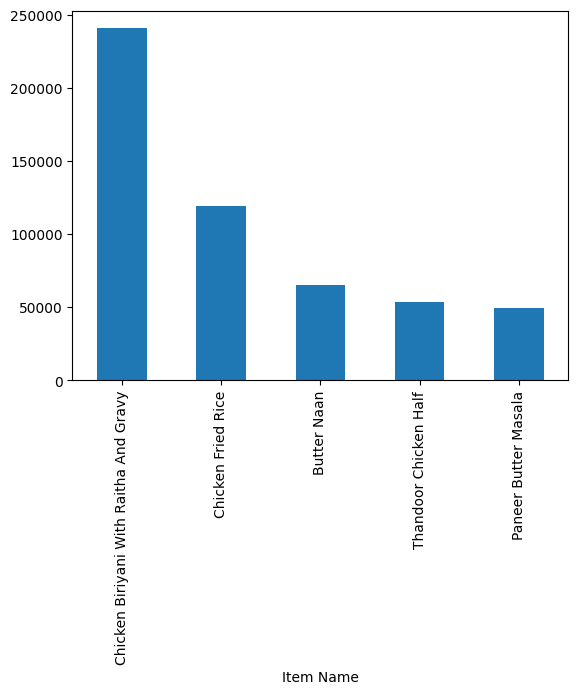

In [ ]:
b.plot(kind='bar')

In [ ]:
d=dh.groupby(dh['Date'])['Final Total'].sum()

In [ ]:
d

,Final Total
Date,
2023-04-01,16601.56
2023-04-02,9780.50
2023-04-03,6643.86
2023-04-04,10898.96
2023-04-05,10624.98
...,...
2023-09-15,21042.02
2023-09-16,14305.22
2023-09-17,18779.20


<Axes: xlabel='Date'>

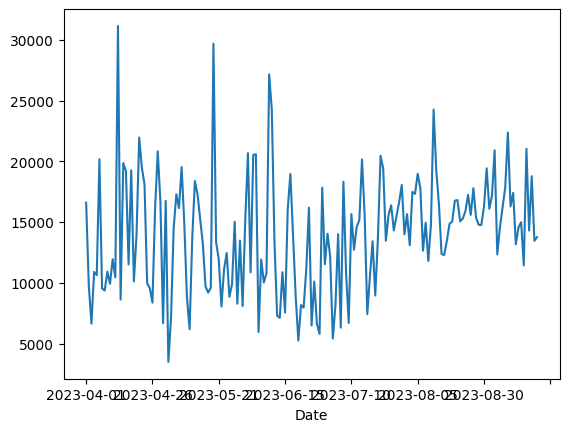

In [ ]:
d.plot(kind='line')

In [ ]:
e = dh.loc[(dh['Date'] == '2023-09-15') & (dh['Item Name'] == 'Chicken Noodles'), 'Qty.'].sum()


In [ ]:
e

np.float64(7.0)

In [ ]:
f=dh.groupby(['Invoice No.'])['Final Total'].sum()
f[f>=2000]

,Final Total
Invoice No.,
23499,2533.64
23508,2011.00
23637,5644.82
23718,3517.50
23827,22638.00
...,...
28014,3013.68
28126,2887.50
28145,4078.68


In [ ]:

f

,Final Total
Invoice No.,
23465,1134.00
23466,441.00
23467,774.88
23468,273.00
23469,462.00
...,...
28385,493.50
28386,1479.44
28387,1501.50


In [ ]:

g=dh.loc[dh['Invoice No.'] == '28145', ['Qty.', 'Final Total', 'Item Name']]


In [ ]:
g['Qty.'].sum()

np.float64(0.0)

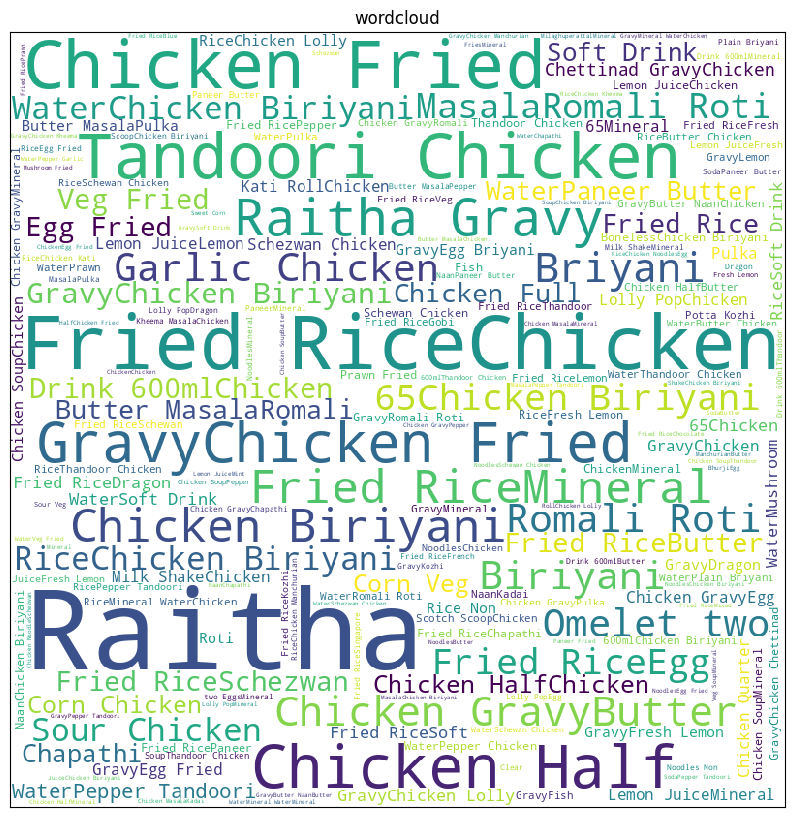

In [ ]:
from wordcloud import WordCloud
text=''.join(dh['Item Name'].dropna().astype(str).values)
wordcloud=WordCloud(background_color='white',width=800,height=800).generate(text)
fig,ax=plt.subplots(figsize=(10,16))
ax.imshow(wordcloud,interpolation='nearest')
ax.set_title('wordcloud')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [ ]:
dh[dh['Price'] > 100][['Item Name', 'Price']]

,Item Name,Price
0,Babycorn Manchurian,160.0
1,Chicken Kati Roll,120.0
2,Paneer Butter Masala,150.0
4,Schewan Chicken Fried Rice,160.0
5,Schezwan Egg Fried Rice,140.0
...,...,...
15613,Prawn Chilli,199.0
15614,Schezwan Mushroom Fried Rice,140.0
15615,Gobi- 65,120.0
15618,Mushroom Masala,150.0


In [ ]:
df.loc[df['Price'] > 200,'Item Name']

,Item Name
171,Pepper Tandoori Chicken ( Half )
337,Grill Chicken (full)
354,Pepper Tandoori Chicken ( Half )
440,Thandoor Chicken Full
622,Pepper Tandoori Chicken ( Half )
...,...
6919,Pepper Tandoori Chicken ( Full )
6982,Pepper Tandoori Chicken ( Half )
6990,Pepper Tandoori Chicken ( Half )
7033,Pepper Tandoori Chicken ( Half )


In [ ]:
revenue = df.groupby('Item Name')['Final Total'].sum().reset_index()
revenue['Rank'] = revenue['Final Total'].rank(ascending=False)
revenue.sort_values('Rank')


,Item Name,Final Total,Rank
27,Chicken Biriyani With Raitha And Gravy,142516.08,1.0
30,Chicken Fried Rice,66679.20,2.0
16,Butter Naan,30561.32,3.0
38,Chicken Noodles,25892.16,4.0
166,Paneer Butter Masala,22617.14,5.0
...,...,...,...
238,Tomato Soup,84.00,245.0
242,Veg Kothu Parata,73.50,246.0
239,Vechhu Paratha (1 No),52.50,247.0
84,Full Boil,42.00,248.5
